In [ ]:
import pandas as pd
import requests

# This is the actual URL from your screenshot
url = "https://stats.baseboll-softboll.se/en/events/2025-regionserien-baseboll/teams/36163"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

try:
    response = requests.get(url, headers=headers)
    # Read HTML directly here
    tables = pd.read_html(response.text)
    
    print(f"Found {len(tables)} tables")
    # Roster in screenshot is the largest table on the left, usually tables[0]
    df_roster = tables[0]
    print(df_roster.head())
    
except Exception as e:
    print(f"Reading failed: {e}")

找到 2 個表格
    #             Player            POS  B/T   YOB
0  81   Andreasson David       LF/CF/RF  R/R  1997
1  50      Falk Amos Ayo    1B/2B/3B/SS  R/R  2007
2  16    Ferris Jonathan     P/1B/2B/SS  R/R  1981
3   3        Gilman Adam          1B/3B  R/R  1982
4  90  Gyllenberg Viktor  P/1B/2B/SS/LF  R/L  1987


C:\Users\dechihao\AppData\Local\Temp\ipykernel_22324\3468810926.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [ ]:
import pandas as pd
import requests
import io

url = "https://stats.baseboll-softboll.se/en/events/2025-regionserien-baseboll/teams/36163"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

response = requests.get(url, headers=headers)

print(f"Status Code: {response.status_code}")

if response.status_code == 200:
    # Check the first 200 characters of the webpage content to see if it's normal HTML
    print("Web content preview:", response.text[:200])
    
    try:
        # Try specifying parser 'lxml', which is usually more powerful than default
        # If error says no lxml, run in terminal: pip install lxml
        tables = pd.read_html(io.StringIO(response.text), flavor='lxml')
        print(f"Successfully found {len(tables)} tables")
        df_roster = tables[0]
        print(df_roster.head())
    except Exception as e:
        print(f"Error parsing tables: {e}")
else:
    print("Request failed, please check network or URL")

狀態碼 (Status Code): 200
網頁內容預覽: <!DOCTYPE html>
<html lang="en">
<head>
            <title>Stockholm B - Regionserien Baseboll 2025</title>
    <meta charset="utf-8">
    <meta name="robots" content="index,follow,max-image-preview:l
成功找到 2 個表格
    #             Player            POS  B/T   YOB
0  81   Andreasson David       LF/CF/RF  R/R  1997
1  50      Falk Amos Ayo    1B/2B/3B/SS  R/R  2007
2  16    Ferris Jonathan     P/1B/2B/SS  R/R  1981
3   3        Gilman Adam          1B/3B  R/R  1982
4  90  Gyllenberg Viktor  P/1B/2B/SS/LF  R/L  1987


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df_roster is the first table you scraped
df = df_roster.copy()

# 1. Fix column names (remove possible spaces)
df.columns = [c.strip() for c in df.columns]

# 2. Fix YOB (Year of Birth)
# Preview shows '19971', usually YOB field is stuck with the next row's index
# We only take the first four digits and convert to integer
df['YOB'] = df['YOB'].astype(str).str[:4]
df['YOB'] = pd.to_numeric(df['YOB'], errors='coerce')

# 3. Process height, weight or other values (if any)
# 4. Calculate age (currently 2026)
df['Age'] = 2026 - df['YOB']

print("Data after cleaning:")
print(df[['Player', 'POS', 'B/T', 'Age']].head())

清洗後的數據：
              Player            POS  B/T  Age
0   Andreasson David       LF/CF/RF  R/R   29
1      Falk Amos Ayo    1B/2B/3B/SS  R/R   19
2    Ferris Jonathan     P/1B/2B/SS  R/R   45
3        Gilman Adam          1B/3B  R/R   44
4  Gyllenberg Viktor  P/1B/2B/SS/LF  R/L   39


In [ ]:
df['Pos_Count'] = df['POS'].str.count('/') + 1
print(f"Team average positions per player: {df['Pos_Count'].mean():.2f}")

全隊平均每人可守備 3.24 個位置


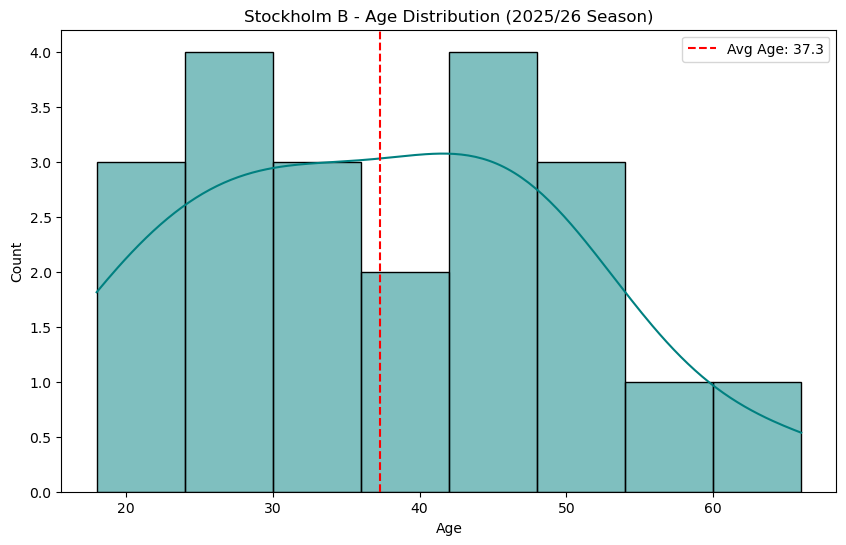

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=8, kde=True, color='teal')
plt.title('Stockholm B - Age Distribution (2025/26 Season)')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Avg Age: {df["Age"].mean():.1f}')
plt.legend()
plt.show()

In [ ]:
df[['Bats', 'Throws']] = df['B/T'].str.split('/', expand=True)
print("Batting handedness distribution:")
print(df['Bats'].value_counts(normalize=True))

打擊習慣分佈：
Bats
R    0.904762
L    0.095238
Name: proportion, dtype: float64
